In [63]:
import numpy as np
import pygsp
A = np.random.normal(size=(10,5))
for i in range(A.shape[0]):
    print(pygsp.graphs.NNGraph(A, k=5).W.todense()[i,i])

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [3]:
import numpy as np
import json
import phate
import scprep
import scipy

## 1.0 Analyzing localization output

```
python train.py --model Signals --task localization --seed 0
```

In [6]:
tmpN = 100
save_as = 0
task = 'localization'
model = 'MAGIC'
prefix = f'results/{task}/{model}/{save_as}'
    
results = np.load(f'{prefix}_results.npz', allow_pickle=True)
localization_truth = np.load('./data/localization_signals.npz')['spread']
embedding = results['signal_embedding']
localization_score = results['localization_score']
config = results['config'][()]

In [8]:
config

{'lr': 0.01,
 'dropout': 0.0,
 'epochs': 100,
 'weight_decay': 0.0,
 'patience': 50,
 'min_epochs': 50,
 'seed': 1234,
 'walk_length': 80,
 'num_walks': 10,
 'task': 'localization',
 'verbose': 1,
 'model': 'MAGIC',
 'dim': 16,
 'num_layers': 2,
 'bias': 1,
 'act': 'relu',
 'num_classes': 2,
 'k_neighbors': 5,
 'device': 'cpu',
 'val_prop': 0.05,
 'test_prop': 0.1,
 'split_seed': 1234,
 'save_as': '0',
 'comparison': 'Projection'}

In [9]:
phate_op = phate.PHATE(random_state=config['seed'], verbose=False)
data_phate = phate_op.fit_transform(embedding)

    Using SMACOF because SGD returned NaN


/home/aarthivenkat/.local/lib/python3.8/site-packages/graphtools/graphs.py:290: RuntimeWarning: Detected zero distance between 3500 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
/home/aarthivenkat/.local/lib/python3.8/site-packages/graphtools/graphs.py:454: RuntimeWarning: overflow encountered in power
  K.data = np.exp(-1 * np.power(K.data, self.decay))
/home/aarthivenkat/.local/lib/python3.8/site-packages/graphtools/base.py:554: RuntimeWarning: K should have a non-zero diagonal
  warnings.warn("K should have a non-zero diagonal", RuntimeWarning)


<AxesSubplot:title={'center':'Signal embedding\nLocalization Truth'}>

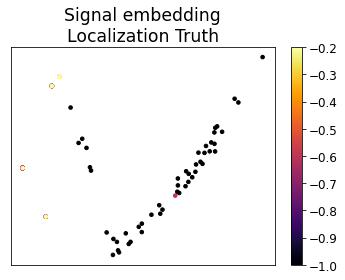

In [10]:
scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4),
                      c=-1*localization_truth, title='Signal embedding\nLocalization Truth')

<AxesSubplot:title={'center':'Signal embedding\nLocalization Score'}>

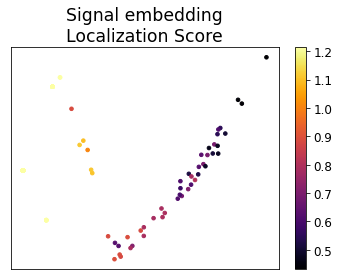

In [11]:
scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4), 
                      c=localization_score, title='Signal embedding\nLocalization Score')

In [12]:
scipy.stats.spearmanr(-1*localization_truth, localization_score).statistic

0.6865340484386566

## 1.1 Analyzing coexpression output

In [18]:
task = 'coexpression'
prefix = f'results/{task}/{model}/{save_as}'
    
results = np.load(f'{prefix}_results.npz', allow_pickle=True)
localization_truth = np.load('./data/localization_signals.npz')['spread']
embedding = results['signal_embedding']
localization_score = results['localization_score']
config = results['config'][()]

In [19]:
config

{'lr': 0.01,
 'dropout': 0.0,
 'epochs': 100,
 'weight_decay': 0.0,
 'patience': 50,
 'min_epochs': 50,
 'seed': 1234,
 'walk_length': 80,
 'num_walks': 10,
 'task': 'coexpression',
 'verbose': 1,
 'model': 'MAGIC',
 'dim': 16,
 'num_layers': 2,
 'bias': 1,
 'act': 'relu',
 'num_classes': 2,
 'k_neighbors': 5,
 'device': 'cpu',
 'val_prop': 0.05,
 'test_prop': 0.1,
 'split_seed': 1234,
 'save_as': '0',
 'comparison': 'Projection'}

In [20]:
phate_op = phate.PHATE(random_state=config['seed'], verbose=config['verbose'])
data_phate = phate_op.fit_transform(embedding)

Calculating PHATE...
  Running PHATE on 8821 observations and 16 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.69 seconds.
    Calculating affinities...
    Calculated affinities in 0.08 seconds.
  Calculated graph and diffusion operator in 0.78 seconds.
  Calculating landmark operator...
    Calculating SVD...


/home/aarthivenkat/.local/lib/python3.8/site-packages/graphtools/graphs.py:290: RuntimeWarning: Detected zero distance between 13598 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
/home/aarthivenkat/.local/lib/python3.8/site-packages/graphtools/graphs.py:454: RuntimeWarning: overflow encountered in power
  K.data = np.exp(-1 * np.power(K.data, self.decay))


    Calculated SVD in 0.99 seconds.
    Calculating KMeans...
    Calculated KMeans in 4.16 seconds.
  Calculated landmark operator in 5.96 seconds.
  Calculating optimal t...
    Automatically selected t = 32
  Calculated optimal t in 1.92 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.32 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.12 seconds.
Calculated PHATE in 13.12 seconds.


<AxesSubplot:title={'center':'Gene embedding\nLocalization Score'}>

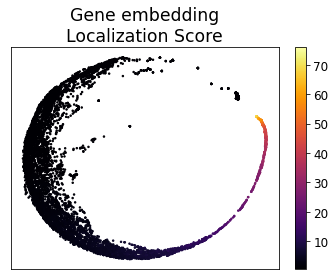

In [21]:
scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4), 
                      c=localization_score, title='Gene embedding\nLocalization Score')